# 🔭 DeepLense: Gravitational Lensing Substructure Classification

**Local Training** — ResNet18 classifier for 3 classes of strong gravitational lensing images.

| Class | Label | Description |
|-------|-------|-------------|
| `no`  | 0     | No substructure |
| `sphere` | 1  | Subhalo (spherical) substructure |
| `vort` | 2    | Vortex substructure |

**Dataset:** `.npy` files, shape `(1, 150, 150)`, min-max normalized `[0, 1]`  
**Train:** 10,000 × 3 classes = 30,000 | **Val:** 2,500 × 3 = 7,500

## 1. Imports & Configuration

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torchvision import transforms, models
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from pathlib import Path
import json

# ── Configuration ──────────────────────────────────────────────────────
TRAIN_DIR    = "/home/vidit68/Desktop/drive/tasks/common_task/dataset/train"
VAL_DIR      = "/home/vidit68/Desktop/drive/tasks/common_task/dataset/val"
MODEL_PATH   = "/home/vidit68/Desktop/drive/Deeplense/best_deeplense_resnet18.pth"
RESULTS_PATH = "/home/vidit68/Desktop/drive/Deeplense/training_results.json"

BATCH_SIZE  = 128   # larger batch = more stable gradients
EPOCHS      = 50
LR          = 3e-4  # lower LR: prevents collapse
NUM_WORKERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device available: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🚀 Device: cuda
   GPU: NVIDIA GeForce RTX 4060 Laptop GPU
   VRAM: 8.2 GB


## 1b. Data Sanity Check

Verify class folder names, counts, and image statistics before training.

In [14]:
print("=" * 50)
print("Dataset Sanity Check")
print("=" * 50)
for split, path in [("train", TRAIN_DIR), ("val", VAL_DIR)]:
    root = Path(path)
    classes = sorted([d.name for d in root.iterdir() if d.is_dir()])
    print(f"\n[{split}] Folder name reprs: {[repr(c) for c in classes]}")
    for cls in classes:
        files = list((root / cls).glob("*.npy"))
        if files:
            sample = np.load(files[0]).astype(np.float32)
            print(f"   {cls!r:15s}: {len(files):5d} files | shape={sample.shape} | "
                  f"min={sample.min():.3f} max={sample.max():.3f} mean={sample.mean():.4f}")

Dataset Sanity Check

[train] Folder name reprs: ["'no'", "'sphere'", "'vort'"]
   'no'           : 10000 files | shape=(1, 150, 150) | min=0.000 max=1.000 mean=0.0660
   'sphere'       : 10000 files | shape=(1, 150, 150) | min=0.000 max=1.000 mean=0.0776
   'vort'         : 10000 files | shape=(1, 150, 150) | min=0.000 max=1.000 mean=0.0615

[val] Folder name reprs: ["'no'", "'sphere'", "'vort'"]
   'no'           :  2500 files | shape=(1, 150, 150) | min=0.000 max=1.000 mean=0.0627
   'sphere'       :  2500 files | shape=(1, 150, 150) | min=0.000 max=1.000 mean=0.0701
   'vort'         :  2500 files | shape=(1, 150, 150) | min=0.000 max=1.000 mean=0.0599


## 2. Dataset & Transforms

In [15]:
class LensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        root = Path(root_dir)
        # Strip whitespace/newlines from folder names to be safe
        self.classes = sorted([d.name.strip() for d in root.iterdir() if d.is_dir()])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.file_paths, self.labels = [], []
        for d in sorted(root.iterdir()):
            if not d.is_dir(): continue
            cls = d.name.strip()
            for f in sorted(d.glob("*.npy")):
                self.file_paths.append(str(f))
                self.labels.append(self.class_to_idx[cls])

    def __len__(self): return len(self.file_paths)

    def __getitem__(self, idx):
        image = np.load(self.file_paths[idx]).astype(np.float32)
        if image.ndim == 2: image = np.expand_dims(image, 0)
        tensor = torch.from_numpy(image)  # already [0,1], shape (1,150,150)
        if self.transform: tensor = self.transform(tensor)
        return tensor, torch.tensor(self.labels[idx], dtype=torch.long)


train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=90),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
])

train_dataset = LensingDataset(TRAIN_DIR, transform=train_transform)
val_dataset   = LensingDataset(VAL_DIR,   transform=None)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

class_names = train_dataset.classes
num_classes = len(class_names)
print(f"Classes:  {train_dataset.class_to_idx}")
print(f"Train:    {len(train_dataset)} samples")
print(f"Val:      {len(val_dataset)} samples")

# Verify label distribution
from collections import Counter
counts = Counter(train_dataset.labels)
print("\nLabel distribution (train):")
for label, count in sorted(counts.items()):
    print(f"   Label {label} ({class_names[label]}): {count}")

Classes:  {'no': 0, 'sphere': 1, 'vort': 2}
Train:    30000 samples
Val:      7500 samples

Label distribution (train):
   Label 0 (no): 10000
   Label 1 (sphere): 10000
   Label 2 (vort): 10000


## 3. Model

In [ ]:
model = models.resnet18(weights=None)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
nn.init.kaiming_normal_(model.conv1.weight, mode='fan_out', nonlinearity='relu')
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ ResNet18 (1-ch → {num_classes}-class) | {total_params:,} params")

with torch.no_grad():
    dummy = torch.randn(4, 1, 150, 150).to(DEVICE)
    out = model(dummy)
    print(f"   Output shape: {out.shape}  (expected: [4, {num_classes}])")
    print(f"   Initial logits: {out[0].cpu().numpy().round(4)}")

✅ ResNet18 (1-ch → 3-class) | 11,171,779 params
   Output shape: torch.Size([4, 3])  (expected: [4, 3])
   Initial logits: [ 0.5673 -0.2206  0.4793]


## 4. Training

Key fixes vs the previous run:
- **No label smoothing** — was masking gradient signal for `vort`
- **ReduceLROnPlateau** instead of CosineAnnealing — adapts to actual progress
- **Lower base LR (3e-4)** — prevents early collapse
- **Larger batch (128)** — more stable gradient estimates

In [ ]:
criterion = nn.CrossEntropyLoss()  # no label smoothing
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2, verbose=True
)
scaler = GradScaler("cuda") if DEVICE.type == "cuda" else None

history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": [], "lr": []}
best_auc = 0.9096

print(f"  Training for {EPOCHS} epochs (bs={BATCH_SIZE}, lr={LR})...")
print(f"   Steps/epoch: {len(train_loader)}\n")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, targets in train_loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        if scaler:
            with autocast("cuda"):
                loss = criterion(model(images), targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss = criterion(model(images), targets)
            loss.backward()
            optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    all_targets, all_probs = [], []

    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            if scaler:
                with autocast("cuda"):
                    outputs = model(images)
                    loss = criterion(outputs, targets)
            else:
                outputs = model(images)
                loss = criterion(outputs, targets)
            val_loss += loss.item()
            probs = torch.softmax(outputs.float(), dim=1)
            _, preds = torch.max(probs, 1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total
    val_auc = roc_auc_score(all_targets, all_probs, multi_class="ovr", average="macro")
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)
    history["lr"].append(current_lr)

    scheduler.step(val_auc)  # reduce LR if AUC plateaus

    marker = ""
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), MODEL_PATH)
        marker = " ✅"

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"| Train: {avg_train_loss:.4f} "
        f"| Val: {avg_val_loss:.4f} "
        f"| Acc: {val_acc:.4f} "
        f"| AUC: {val_auc:.4f} "
        f"| LR: {current_lr:.2e}{marker}"
    )

print(f"\nBest Val AUC: {best_auc:.4f} — saved to {MODEL_PATH}")

⏳ Training for 50 epochs (bs=128, lr=0.0003)...
   Steps/epoch: 235



/home/vidit68/Desktop/drive/Deeplense/conda/envs/lsst-scipipe-10.1.0/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [01/50] | Train: 0.4842 | Val: 0.6512 | Acc: 0.7493 | AUC: 0.9113 | LR: 3.00e-04 ✅
Epoch [02/50] | Train: 0.4644 | Val: 0.4807 | Acc: 0.7889 | AUC: 0.9395 | LR: 3.00e-04 ✅
Epoch [03/50] | Train: 0.4470 | Val: 1.5870 | Acc: 0.4360 | AUC: 0.8772 | LR: 3.00e-04
Epoch [04/50] | Train: 0.4320 | Val: 0.6379 | Acc: 0.7385 | AUC: 0.9080 | LR: 3.00e-04
Epoch [05/50] | Train: 0.4117 | Val: 0.7695 | Acc: 0.6987 | AUC: 0.9073 | LR: 3.00e-04
Epoch [06/50] | Train: 0.3595 | Val: 0.4614 | Acc: 0.8143 | AUC: 0.9541 | LR: 1.50e-04 ✅
Epoch [07/50] | Train: 0.3434 | Val: 0.3715 | Acc: 0.8488 | AUC: 0.9587 | LR: 1.50e-04 ✅
Epoch [08/50] | Train: 0.3324 | Val: 0.3184 | Acc: 0.8691 | AUC: 0.9690 | LR: 1.50e-04 ✅
Epoch [09/50] | Train: 0.3238 | Val: 0.3062 | Acc: 0.8787 | AUC: 0.9704 | LR: 1.50e-04 ✅
Epoch [10/50] | Train: 0.3160 | Val: 0.3350 | Acc: 0.8627 | AUC: 0.9665 | LR: 1.50e-04
Epoch [11/50] | Train: 0.3045 | Val: 0.3472 | Acc: 0.8607 | AUC: 0.9681 | LR: 1.50e-04
Epoch [12/50] | Train: 0.2964 |

KeyboardInterrupt: 

## 5. Final Evaluation

In [ ]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_targets, all_probs, all_preds = [], [], []
with torch.no_grad():
    for images, targets in val_loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs.float(), dim=1)
        _, preds = torch.max(probs, 1)
        all_targets.extend(targets.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_targets = np.array(all_targets)
all_probs   = np.array(all_probs)
all_preds   = np.array(all_preds)

final_auc = roc_auc_score(all_targets, all_probs, multi_class="ovr", average="macro")
print(f"Macro ROC-AUC: {final_auc:.4f}\n")
print(classification_report(all_targets, all_preds, target_names=class_names))

#Class prediction counts
print("Predictions per class:")
from collections import Counter
pred_counts = Counter(all_preds.tolist())
for label, count in sorted(pred_counts.items()):
    print(f"   Label {label} ({class_names[label]}): {count} predictions")

#Saving results
cm = confusion_matrix(all_targets, all_preds).tolist()
roc_data = {}
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve((all_targets == i).astype(int), all_probs[:, i])
    roc_data[cls] = {"fpr": fpr.tolist(), "tpr": tpr.tolist(), "auc": float(auc(fpr, tpr))}

results = {
    "history": history,
    "final_auc": float(final_auc),
    "confusion_matrix": cm,
    "roc_data": roc_data,
    "class_names": class_names,
}
with open(RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)
print(f"\nSaved to {RESULTS_PATH}")

/tmp/ipykernel_22714/1587253008.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))


Macro ROC-AUC: 0.9896

              precision    recall  f1-score   support

          no       0.93      0.98      0.96      2500
      sphere       0.94      0.88      0.91      2500
        vort       0.94      0.94      0.94      2500

    accuracy                           0.94      7500
   macro avg       0.94      0.94      0.94      7500
weighted avg       0.94      0.94      0.94      7500

Predictions per class:
   Label 0 (no): 2640 predictions
   Label 1 (sphere): 2341 predictions
   Label 2 (vort): 2519 predictions

📁 Results saved to /home/vidit68/Desktop/drive/Deeplense/training_results.json


## 6. Visualization

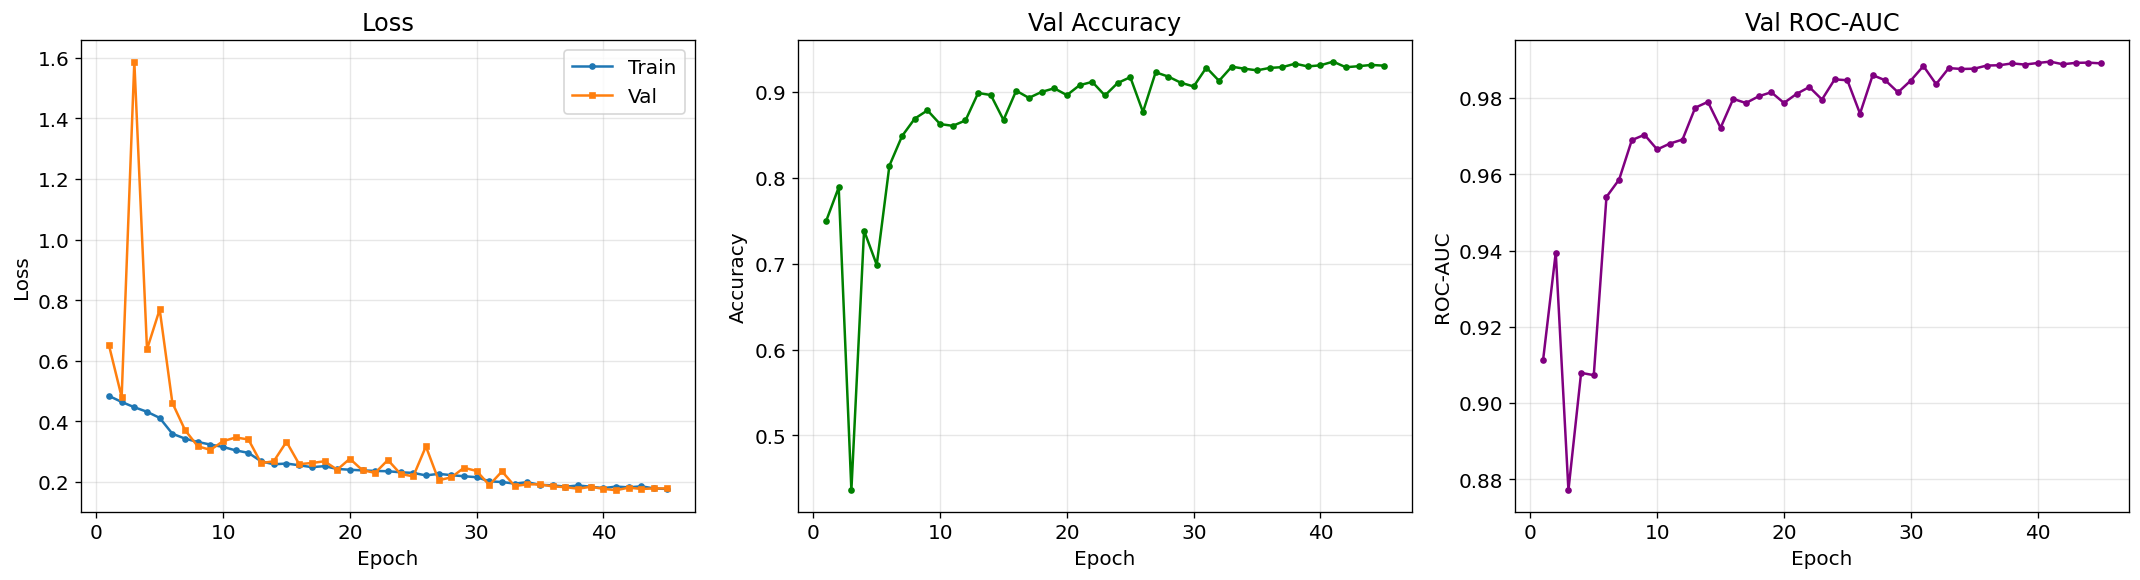

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 12, "figure.dpi": 120})

epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history["train_loss"], "o-", label="Train", markersize=3)
axes[0].plot(epochs_range, history["val_loss"], "s-", label="Val", markersize=3)
axes[0].set(xlabel="Epoch", ylabel="Loss", title="Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["val_acc"], "o-", color="green", markersize=3)
axes[1].set(xlabel="Epoch", ylabel="Accuracy", title="Val Accuracy")
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history["val_auc"], "o-", color="purple", markersize=3)
axes[2].set(xlabel="Epoch", ylabel="ROC-AUC", title="Val ROC-AUC")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig("/home/vidit68/Desktop/drive/Deeplense/training_curves.png", bbox_inches="tight")
plt.show()

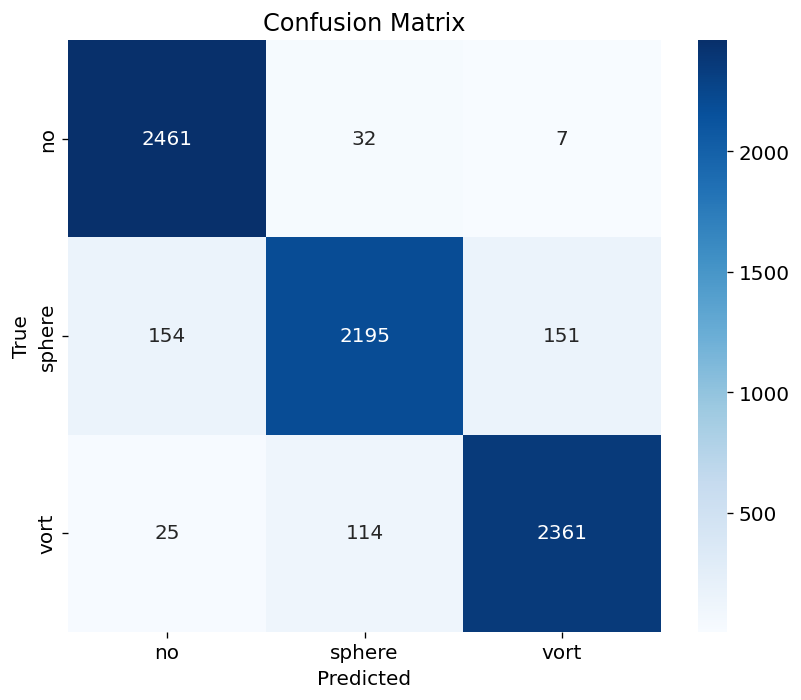

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(np.array(cm), annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set(xlabel="Predicted", ylabel="True", title="Confusion Matrix")
plt.tight_layout()
# plt.savefig("/home/vidit68/Desktop/drive/Deeplense/confusion_matrix.png", bbox_inches="tight")
plt.show()

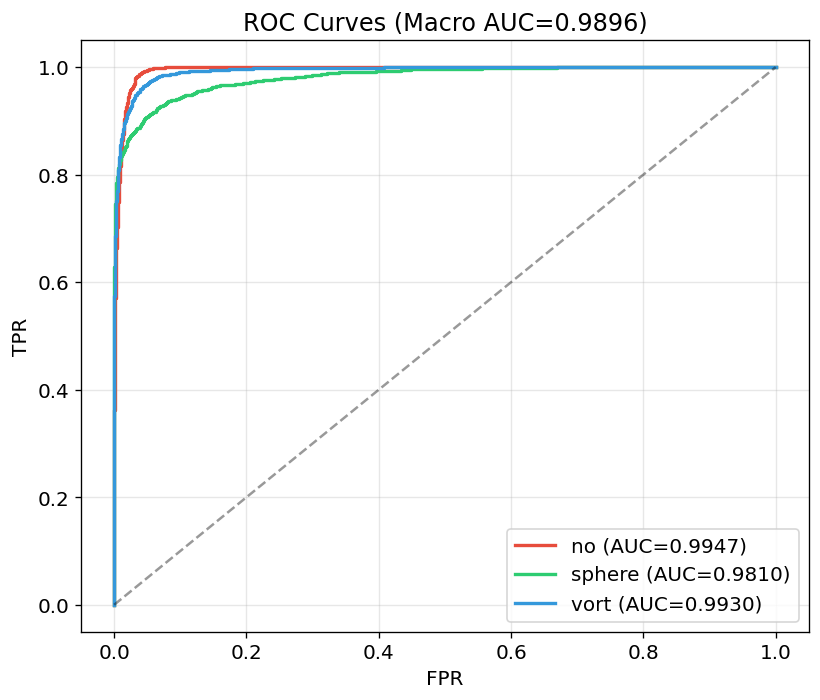

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#e74c3c", "#2ecc71", "#3498db"]
for i, cls in enumerate(class_names):
    d = roc_data[cls]
    ax.plot(d["fpr"], d["tpr"], color=colors[i], label=f"{cls} (AUC={d['auc']:.4f})", lw=2)
ax.plot([0,1],[0,1], "k--", alpha=0.4)
ax.set(xlabel="FPR", ylabel="TPR", title=f"ROC Curves (Macro AUC={final_auc:.4f})")
ax.legend(loc="lower right"); ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig("/home/vidit68/Desktop/drive/Deeplense/roc_curves.png", bbox_inches="tight")
plt.show()

## 7. Inference Demo

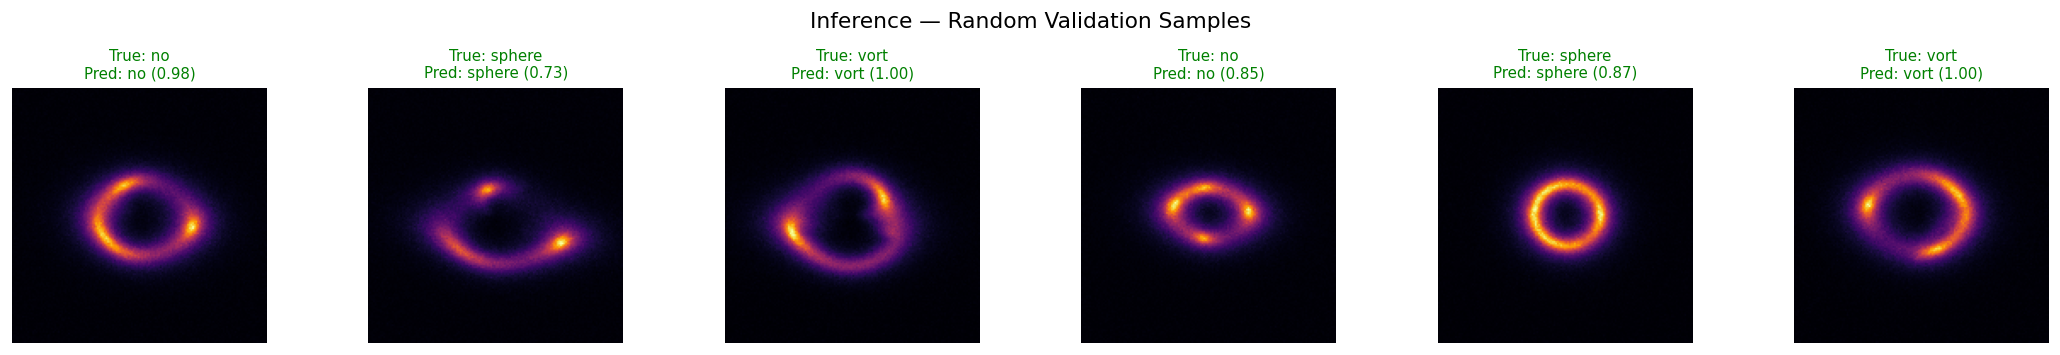

In [ ]:
import random

val_root = Path(VAL_DIR)
fig, axes = plt.subplots(1, 6, figsize=(18, 3))

for i, ax in enumerate(axes):
    cls = class_names[i % 3]
    cls_dir = next(d for d in val_root.iterdir() if d.name.strip() == cls)
    f = random.choice(list(cls_dir.glob("*.npy")))
    img = np.load(f).astype(np.float32)
    if img.ndim == 2: img = np.expand_dims(img, 0)
    tensor = torch.from_numpy(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0].cpu()
    pred_idx = probs.argmax().item()

    ax.imshow(img[0], cmap="inferno", origin="lower")
    color = "green" if class_names[pred_idx] == cls else "red"
    ax.set_title(f"True: {cls}\nPred: {class_names[pred_idx]} ({probs[pred_idx]:.2f})",
                 fontsize=9, color=color)
    ax.axis("off")

plt.suptitle("Inference — Random Validation Samples", fontsize=13)
plt.tight_layout()
# plt.savefig("/home/vidit68/Desktop/drive/Deeplense/inference_demo.png", bbox_inches="tight")
plt.show()